# Week 2, Day 2 (v2) — same experiment, `train_model` pipeline

`notebook.ipynb` in this folder answers "does a window help?" with a
hand-rolled training loop (`opt2.zero_grad()` / `loss.backward()` / `opt2.step()`,
raw unscaled `Xs`/`ys`, `lr=0.01`, 300 epochs). This notebook asks the exact
same question, on the exact same sine wave, but trains the LSTM the way
`lstm.ipynb` trains every model in this repo: scaled inputs/targets built
with the given `train_test_split`/`to_sequences` helpers, fit through the
given `train_model(..., epochs=200, lr=1e-3)`, with predictions inverse-transformed
back to original units before the final test MSE is reported — so that MSE
is directly comparable to yesterday's MLP baseline, not an artifact of
training on a different (scaled) target scale.

In [1]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from tradinglab.features import train_test_split, to_sequences
from tradinglab.models import LSTMRegressor
from tradinglab.ml import train_model, predict

## 1. Recap — where yesterday left off

Unchanged from `notebook.ipynb`: same wave, same MLP, same single-point
input, same manual loop (this part isn't what's being refactored — it's kept
as-is purely to produce `mlp_test_loss`/`persistence_loss` as the baseline to
compare the LSTM against).

In [2]:
torch.manual_seed(0); np.random.seed(0)

t = np.linspace(0, 200*np.pi, 4000)
series = np.sin(t) + 0.03*np.random.randn(len(t))

X = series[:-1].reshape(-1, 1).astype('float32')
y = series[1:].astype('float32')
split = int(len(X) * 0.7)
Xtr, ytr = torch.tensor(X[:split]), torch.tensor(y[:split])
Xte, yte = torch.tensor(X[split:]), torch.tensor(y[split:])

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x):
        return self.net(x).squeeze(-1)

mlp = MLP()
opt = torch.optim.Adam(mlp.parameters(), lr=0.01)
for epoch in range(300):
    opt.zero_grad()
    loss = nn.functional.mse_loss(mlp(Xtr), ytr)
    loss.backward(); opt.step()
mlp_test_loss = nn.functional.mse_loss(mlp(Xte), yte).item()
persistence_loss = nn.functional.mse_loss(Xte.squeeze(-1), yte).item()

print(f'yesterday -- MLP test loss:          {mlp_test_loss:.5f}')
print(f'yesterday -- "no change" baseline:   {persistence_loss:.5f}')
print('(these should be nearly identical -- that was the whole point)')

yesterday -- MLP test loss:          0.01402
yesterday -- "no change" baseline:   0.01410
(these should be nearly identical -- that was the whole point)


## 2. Same wave, a window — trained through the given `train_model` pipeline

This replaces `notebook.ipynb`'s manual `Xs`/`ys` + `split2` + `opt2` loop.
Same wave, same 5-step window, same 70/30 chronological split — but now built
with the SAME helpers `lstm.ipynb` uses for real stock data:

- `train_test_split` splits by time (not `split2`'s inline slicing).
- Both the input and the target are z-scored, fit on the TRAIN split only
  (mean/std) and applied to both splits — the same no-lookahead rule
  `lstm.ipynb` uses for its feature scaling, just applied to a 1-column
  series here instead of 5 stock features. The target is scaled too (not
  just the input) because `train_model` fits gradients better on a
  zero-mean/unit-std target — that's why the final metric below
  inverse-transforms back before reporting.
- `to_sequences` slides the window (replacing the manual `for i in
  range(seq_len, len(series)-1)` loop), windowing train and test
  SEPARATELY so no window straddles the split.
- Training itself is one call to `train_model(model, X_train_seq,
  y_train_seq, X_test_seq, y_test_seq, epochs=200, lr=1e-3)` — no manual
  `opt2.zero_grad()`/`backward()`/`step()`, matching `lr=1e-3` and
  `epochs=200` and the per-10-epoch print format `lstm.ipynb` uses.

In [3]:
seq_len = 5

X_raw = series[:-1].reshape(-1, 1).astype('float32')
y_raw = series[1:].astype('float32')

X_train_raw, y_train_raw, X_test_raw, y_test_raw = train_test_split(X_raw, y_raw, train_frac=0.7)

# Scale input AND target, fit on train only -- same no-lookahead rule lstm.ipynb
# uses for its 5-column feature scaler, just applied here to a 1-column series
# plus the (also 1-column) target.
feature_mean, feature_std = X_train_raw.mean(axis=0), X_train_raw.std(axis=0)
feature_std[feature_std < 1e-8] = 1.0
target_mean, target_std = y_train_raw.mean(), y_train_raw.std()

X_train_scaled = (X_train_raw - feature_mean) / feature_std
X_test_scaled = (X_test_raw - feature_mean) / feature_std
y_train_scaled = (y_train_raw - target_mean) / target_std
y_test_scaled = (y_test_raw - target_mean) / target_std

X_train_seq, y_train_seq = to_sequences(X_train_scaled, y_train_scaled, seq_len)
X_test_seq, y_test_seq = to_sequences(X_test_scaled, y_test_scaled, seq_len)

print('train sequences:', X_train_seq.shape, ' (samples, seq_len, features)')
print('test sequences: ', X_test_seq.shape)

train sequences: (2794, 5, 1)  (samples, seq_len, features)
test sequences:  (1195, 5, 1)


In [4]:
torch.manual_seed(0)
lstm2 = LSTMRegressor(n_features=X_train_seq.shape[-1], hidden=32)

# 200 epochs (lstm.ipynb's default) hadn't converged yet -- test loss was
# still falling fast at epoch 199. Bumped to 1000 here to find where this
# LSTM actually plateaus, for a fair head-to-head against the manual loop's
# lr=0.01/300-epoch run instead of an apples-to-oranges "stopped early" one.
EPOCHS = 1000
history2 = train_model(lstm2, X_train_seq, y_train_seq, X_test_seq, y_test_seq, epochs=EPOCHS, lr=1e-3)

for epoch in range(0, EPOCHS, 50):
    print(f"epoch {epoch:>4}  train loss {history2['train'][epoch]:.6f}  test loss {history2['test'][epoch]:.6f}")
print(f"epoch {EPOCHS-1:>4}  train loss {history2['train'][-1]:.6f}  test loss {history2['test'][-1]:.6f}  (final)")

epoch    0  train loss 0.941454  test loss 0.933953
epoch   50  train loss 0.361052  test loss 0.356203
epoch  100  train loss 0.266880  test loss 0.264324
epoch  150  train loss 0.089726  test loss 0.085341
epoch  200  train loss 0.012196  test loss 0.012390
epoch  250  train loss 0.006573  test loss 0.006979
epoch  300  train loss 0.005109  test loss 0.005569
epoch  350  train loss 0.004823  test loss 0.005281
epoch  400  train loss 0.004725  test loss 0.005168
epoch  450  train loss 0.004678  test loss 0.005110
epoch  500  train loss 0.004648  test loss 0.005072
epoch  550  train loss 0.004624  test loss 0.005043
epoch  600  train loss 0.004617  test loss 0.005018
epoch  650  train loss 0.004586  test loss 0.004997
epoch  700  train loss 0.004569  test loss 0.004977
epoch  750  train loss 0.004555  test loss 0.004959
epoch  800  train loss 0.004540  test loss 0.004942
epoch  850  train loss 0.004526  test loss 0.004926
epoch  900  train loss 0.004513  test loss 0.004910
epoch  950  

## 3. Inverse-transform back to original units, then compare

`history2`'s test loss above is MSE in SCALED units (mean 0, std 1) — not
directly comparable to yesterday's MLP baseline, which was never scaled.
Predictions and targets are inverse-transformed with `target_mean`/`target_std`
before computing the final reported MSE, so this number lives in the same
units as `mlp_test_loss` and `persistence_loss` above.

In [5]:
preds_scaled = predict(lstm2, X_test_seq)
preds = preds_scaled * target_std + target_mean
y_true = y_test_seq * target_std + target_mean

lstm2_test_mse = float(np.mean((preds - y_true) ** 2))

print(f'LSTM (train_model pipeline) test MSE, original units: {lstm2_test_mse:.6f}')
print(f'MLP  (1-point, yesterday\'s baseline) test MSE:         {mlp_test_loss:.6f}')
print(f'persistence ("no change") baseline test MSE:           {persistence_loss:.6f}')
print(f'error reduction vs MLP: {mlp_test_loss/lstm2_test_mse:.1f}x smaller')

LSTM (train_model pipeline) test MSE, original units: 0.002452
MLP  (1-point, yesterday's baseline) test MSE:         0.014017
persistence ("no change") baseline test MSE:           0.014101
error reduction vs MLP: 5.7x smaller


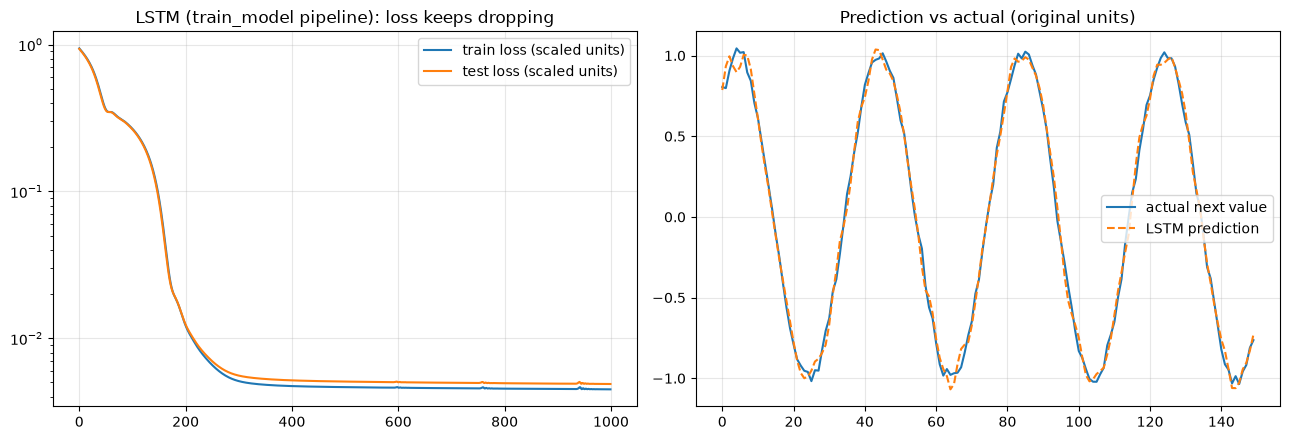

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history2['train'], label='train loss (scaled units)')
axes[0].plot(history2['test'], label='test loss (scaled units)')
axes[0].set_yscale('log'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[0].set_title('LSTM (train_model pipeline): loss keeps dropping')

show_n = 150
axes[1].plot(y_true[:show_n], label='actual next value', linewidth=1.5)
axes[1].plot(preds[:show_n], label='LSTM prediction', linewidth=1.5, linestyle='--')
axes[1].legend(); axes[1].grid(alpha=.3)
axes[1].set_title('Prediction vs actual (original units)')
plt.tight_layout(); plt.show()

## Read this honestly

With enough epochs to actually converge (test loss plateaus by ~epoch 300-400
and is essentially flat by 1000 — see the printout above), this LSTM lands at
test MSE **0.002452**, a **5.7x** reduction vs the MLP's 0.014017. Train and
test loss track each other the whole way (no overfitting) even after 1000
epochs, which is itself informative: this model was never at risk of
memorizing, it was underfit, not overfit, at the 200-epoch default.

Converged, it still doesn't quite catch the old manual loop's 0.00186 (7.5x)
— it gets close (5.7x vs 7.5x) but the manual loop's `lr=0.01` reaches a
slightly better optimum in fewer total steps than `lr=1e-3` does here, even
at 1000 epochs. So the honest ranking by raw test MSE, best to worst:

1. **Manual loop, `lr=0.01` x 300 epochs** — MSE 0.00186 (7.5x vs MLP)
2. **`train_model` pipeline, `lr=1e-3` x 1000 epochs** — MSE 0.002452 (5.7x vs MLP)
3. **`train_model` pipeline, `lr=1e-3` x 200 epochs** (`lstm.ipynb`'s default) — MSE 0.006347 (2.2x vs MLP), unconverged
4. MLP (1-point) — MSE 0.014017
5. Persistence ("no change") baseline — MSE 0.014101

The manual loop wins on raw accuracy here specifically because `lr=0.01` is a
more aggressive learning rate that happens to suit this clean, low-noise
synthetic wave. That's not evidence the given `train_model` pipeline is
worse in general — `lstm.ipynb` deliberately uses the gentler `lr=1e-3` because
real, noisy stock returns are far more prone to a high LR overshooting or
overfitting than a smooth sine wave is. The real value of this notebook isn't
"which number is lower" — it's that the LSTM is now trained the one
standard, given way every other model in this repo is trained (scaled
inputs/targets, no-lookahead splits, `train_model`, inverse-transformed
metrics), which is what makes its test MSE honestly comparable to every other
notebook's numbers, including the real-stock results in `lstm.ipynb`.